# Tutorial 11B: Panel Data Stochastic Frontier Analysis

**Duration**: 3-4 hours | **Level**: Intermediate | **Prerequisites**: Tutorial 01 (Introduction to SFA)

---

## Learning Objectives

By the end of this tutorial, you will be able to:

1. **Extend** SFA concepts from cross-section to panel data
2. **Distinguish** between time-invariant and time-varying inefficiency
3. **Estimate** and **interpret** Pitt-Lee (1981) models
4. **Apply** Battese-Coelli 1992 (BC92) time-decay models
5. **Analyze** inefficiency determinants using BC95 models
6. **Implement** Kumbhakar (1990) flexible time patterns
7. **Use** CSS (distribution-free) methods
8. **Visualize** efficiency evolution over time
9. **Compare** alternative panel SFA specifications
10. **Conduct** model selection for panel data

---

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Exploratory Panel Analysis](#2-exploratory-panel-analysis)
3. [Economic Motivation](#3-economic-motivation)
4. [Theoretical Framework](#4-theoretical-framework)
5. [Pitt-Lee Model (Time-Invariant)](#5-pitt-lee-model)
6. [Battese-Coelli 1992 (Time-Decay)](#6-bc92-model)
7. [LR Test: Pitt-Lee vs BC92](#7-lr-test)
8. [Battese-Coelli 1995 (Determinants)](#8-bc95-model)
9. [Kumbhakar 1990 (Flexible Time)](#9-kumbhakar-model)
10. [CSS (Distribution-Free)](#10-css-model)
11. [Comprehensive Model Comparison](#11-comprehensive-comparison)
12. [Practical Exercises](#12-exercises)
13. [Conclusions and Next Steps](#13-conclusions)
14. [References](#14-references)

---

## 1. Setup and Data Loading <a id='1-setup-and-data-loading'></a>

In [1]:
# Standard imports
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# PanelBox imports
from panelbox.frontier import StochasticFrontier, lr_test

# Set random seed
np.random.seed(42)

# Configure plotting
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

# Create output directories
os.makedirs("../outputs/figures/02_panel", exist_ok=True)
os.makedirs("../outputs/tables/latex", exist_ok=True)
os.makedirs("../outputs/tables/html", exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load panel data
data = pd.read_csv("../data/bank_panel.csv")

# Display structure
print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")

# Check panel structure
print("\nPanel Structure:")
print(f"  Number of entities: {data['bank_id'].nunique()}")
print(f"  Number of periods: {data['year'].nunique()}")
print(f"  Time range: {data['year'].min()} - {data['year'].max()}")

# Check balance
obs_per_entity = data.groupby("bank_id").size()
print(f"  Balanced panel: {obs_per_entity.nunique() == 1}")
print(f"  Observations per entity: min={obs_per_entity.min()}, max={obs_per_entity.max()}")

# Display first observations
print("\nFirst observations:")
data.head(10)

Dataset shape: (1000, 9)
Variables: ['bank_id', 'year', 'log_loans', 'log_labor', 'log_capital', 'log_deposits', 'log_assets', 'public_ownership', 'npl_ratio']

Panel Structure:
  Number of entities: 100
  Number of periods: 10
  Time range: 2010 - 2019
  Balanced panel: True
  Observations per entity: min=10, max=10

First observations:


,bank_id,year,log_loans,log_labor,log_capital,log_deposits,log_assets,public_ownership,npl_ratio
0,1,2010,7.965292,5.346143,7.020278,7.676855,8.902532,0,4.3857
1,1,2011,8.809835,5.634560,7.827680,9.180130,10.429635,0,3.8974
2,1,2012,7.828064,5.784570,7.577425,7.142288,8.479098,0,3.7681
3,1,2013,8.303707,5.682267,7.082071,8.457483,9.453181,0,4.3011
4,1,2014,7.456454,5.969707,7.059217,6.313340,9.112413,0,4.3017
5,1,2015,8.570758,6.340127,8.017609,7.930958,8.598835,0,3.9258
6,1,2016,8.130429,6.052741,6.856871,7.602122,8.328134,0,3.9437
7,1,2017,8.733522,4.937119,7.516013,9.940434,9.353468,0,4.2953
8,1,2018,7.274350,4.158106,6.431799,7.397867,8.057745,0,3.4552
9,1,2019,7.826232,6.232657,7.858125,6.355090,7.858517,0,3.4755


In [3]:
# Summary statistics
print("Summary Statistics:")
data.describe().round(4)

Summary Statistics:


,bank_id,year,log_loans,log_labor,log_capital,log_deposits,log_assets,public_ownership,npl_ratio
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.000,1000.0000
mean,50.5000,2014.5000,7.9767,5.6117,7.0259,7.9690,9.0052,0.290,3.5576
std,28.8805,2.8737,0.9829,1.0478,1.3232,1.2424,1.0388,0.454,1.4281
min,1.0000,2010.0000,5.1123,2.6811,3.7798,3.8815,5.7935,0.000,0.5000
25%,25.7500,2012.0000,7.3362,4.8650,6.1301,7.1419,8.3217,0.000,2.5618
50%,50.5000,2014.5000,7.9739,5.6245,7.0620,7.9919,9.0178,0.000,3.5966
75%,75.2500,2017.0000,8.5737,6.2808,7.7560,8.7737,9.7181,1.000,4.5130
max,100.0000,2019.0000,11.2047,8.6892,12.0548,11.9066,12.2440,1.000,7.8902


---

## 2. Exploratory Panel Analysis <a id='2-exploratory-panel-analysis'></a>

Before estimating frontier models, we explore the data to understand temporal patterns and relationships between variables.

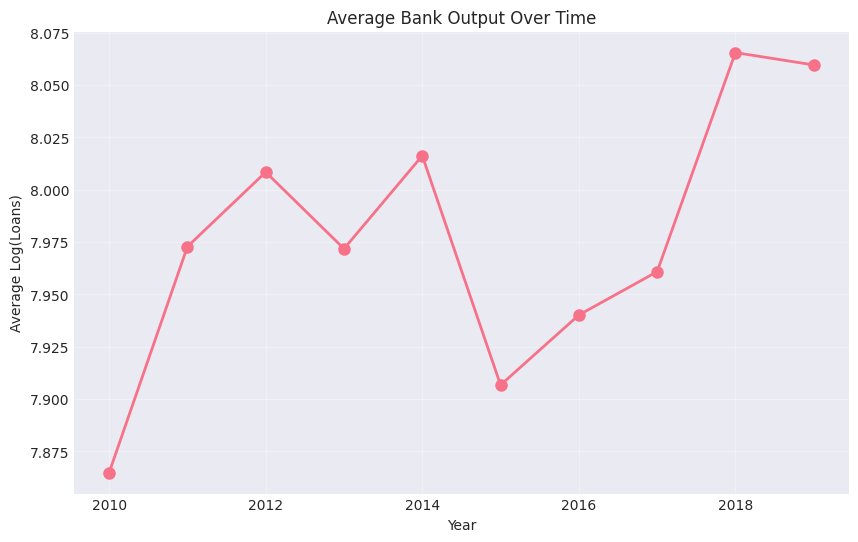

In [4]:
# Time series plot: average output
avg_by_year = data.groupby("year")["log_loans"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg_by_year.index, avg_by_year.values, marker="o", linewidth=2, markersize=8)
ax.set_xlabel("Year")
ax.set_ylabel("Average Log(Loans)")
ax.set_title("Average Bank Output Over Time")
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/02_panel/output_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

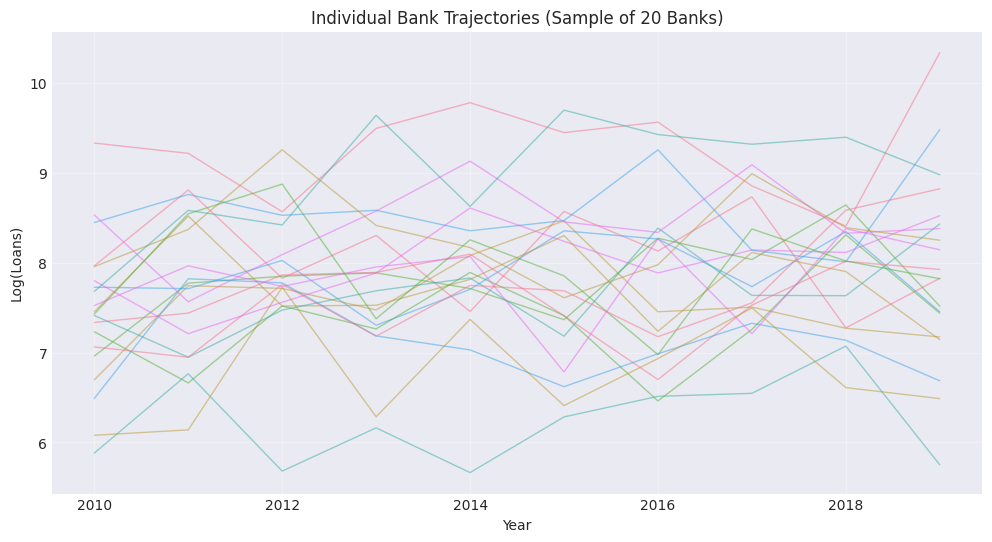

In [5]:
# Spaghetti plot: individual trajectories
fig, ax = plt.subplots(figsize=(12, 6))

# Plot sample of 20 banks
sample_banks = data["bank_id"].unique()[:20]
for bank_id in sample_banks:
    bank_data = data[data["bank_id"] == bank_id]
    ax.plot(bank_data["year"], bank_data["log_loans"], alpha=0.5, linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Log(Loans)")
ax.set_title("Individual Bank Trajectories (Sample of 20 Banks)")
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/02_panel/spaghetti_plot.png", dpi=300, bbox_inches="tight")
plt.show()

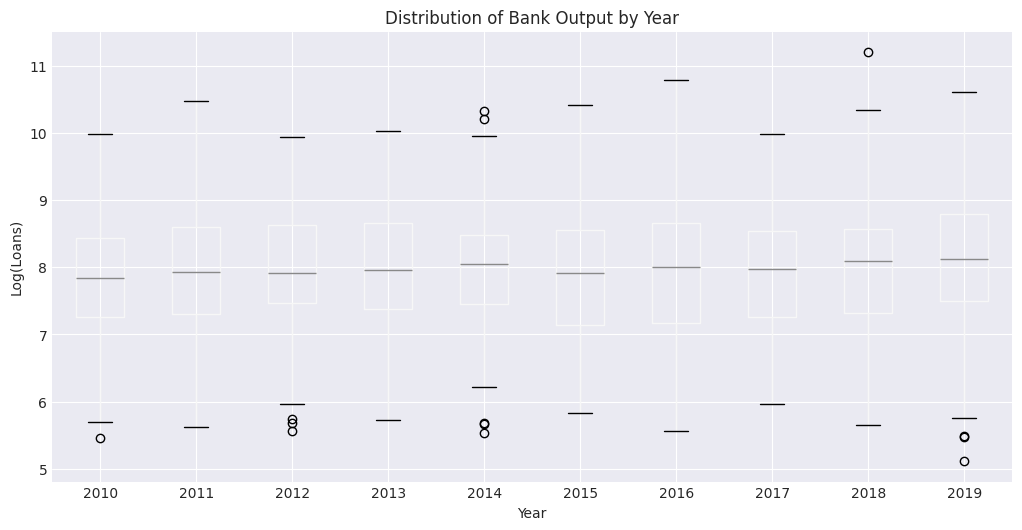

In [6]:
# Distribution by year (boxplot)
fig, ax = plt.subplots(figsize=(12, 6))
data.boxplot(column="log_loans", by="year", ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Log(Loans)")
ax.set_title("Distribution of Bank Output by Year")
ax.get_figure().suptitle("")
plt.savefig(
    "../outputs/figures/02_panel/output_distribution_by_year.png", dpi=300, bbox_inches="tight"
)
plt.show()

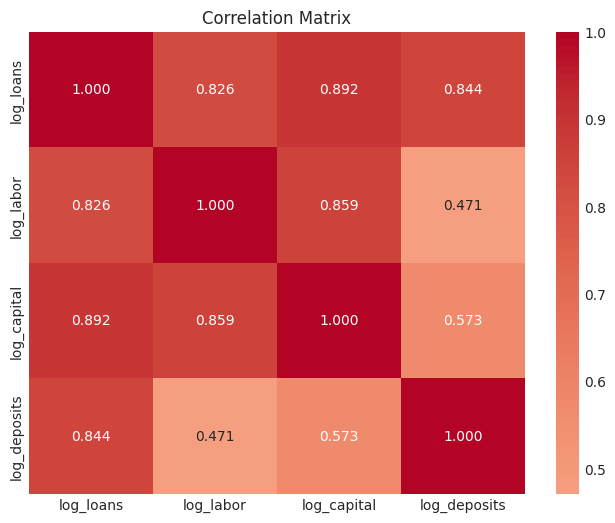

In [7]:
# Correlation matrix
corr_vars = ["log_loans", "log_labor", "log_capital", "log_deposits"]
corr_matrix = data[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.savefig("../outputs/figures/02_panel/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

---

## 3. Economic Motivation <a id='3-economic-motivation'></a>

### The Time Dimension in Efficiency

**Key Question**: Does firm efficiency change over time?

**Real-World Examples**:

1. **Learning-by-Doing**: Banks improve efficiency as they gain experience
   - 2010: New digital bank, TE = 0.70
   - 2015: After 5 years, TE = 0.85
   - Efficiency improves through learning

2. **Technological Adoption**: Manufacturing firms adopt new technologies
   - Early adopters: efficiency increases
   - Late adopters: efficiency lags
   - Heterogeneous learning rates

3. **Management Changes**: Hospital efficiency varies with management quality
   - Good manager hired $\rightarrow$ efficiency increases
   - Manager leaves $\rightarrow$ efficiency decreases
   - Time-varying inefficiency patterns

### Why Panel Data?

**Advantages over Cross-Section**:

| Feature | Cross-Section | Panel Data |
|---------|--------------|------------|
| Observations | N | N $\times$ T |
| Temporal dynamics | No | Yes |
| Separate persistent vs transient | No | Yes |
| Determinants analysis | Limited | Rich |
| Policy evaluation | Snapshot | Over time |

### Motivating Questions

1. **Banking Crisis**: Did bank efficiency decline after 2008 financial crisis?
2. **Technology Adoption**: How fast do firms catch up to the frontier?
3. **Regulatory Reform**: Did deregulation improve airline efficiency?
4. **Management Practices**: What firm characteristics reduce inefficiency?

---

## 4. Theoretical Framework <a id='4-theoretical-framework'></a>

### 4.1 Panel Data Structure

**Data**: $(y_{it}, x_{it})$ for $i = 1,\ldots,N$ entities, $t = 1,\ldots,T$ periods.

### 4.2 Pitt-Lee (1981): Time-Invariant Inefficiency

$$y_{it} = x_{it}'\beta + v_{it} - u_i$$

- $u_i$ is **constant** over time (not subscripted by $t$)
- $v_{it} \sim \text{iid } N(0, \sigma^2_v)$: time-varying noise
- $u_i \sim f(\cdot)$: time-invariant inefficiency
- Technical Efficiency: $TE_i = \exp(-u_i)$ for all $t$

**When to use**: Short panels, efficiency believed stable.

### 4.3 Battese-Coelli 1992 (BC92): Time-Decay

$$y_{it} = x_{it}'\beta + v_{it} - u_{it}$$
$$u_{it} = u_i \times \exp[-\eta(t - T)]$$

**Key Parameter $\eta$**:
- $\eta > 0$: Efficiency **improves** over time (learning)
- $\eta < 0$: Efficiency **worsens** over time (degradation)
- $\eta = 0$: Time-invariant (reduces to Pitt-Lee)

### 4.4 Battese-Coelli 1995 (BC95): Determinants

$$u_{it} \sim N^+(\mu_{it}, \sigma^2_u)$$
$$\mu_{it} = Z_{it}'\delta$$

- $\delta_k > 0$: Variable $Z_k$ **increases** inefficiency
- $\delta_k < 0$: Variable $Z_k$ **decreases** inefficiency

### 4.5 Kumbhakar (1990): Flexible Time Pattern

$$u_{it} = B(t) \times u_i$$
$$B(t) = \frac{1}{1 + \exp(b \cdot t + c \cdot t^2)}$$

Can generate U-shape, inverted-U, or monotonic patterns depending on $b$ and $c$.

### 4.6 CSS (Cornwell-Schmidt-Sickles): Distribution-Free

$$y_{it} = x_{it}'\beta + \alpha_i + v_{it}$$

- Estimate by OLS/Within estimator
- Extract $\alpha_i$ (entity fixed effects)
- Inefficiency: $\hat{u}_i = \max(\hat{\alpha}) - \hat{\alpha}_i$
- **No distributional assumptions** on $u$

### 4.7 Model Comparison Overview

| Model | Inefficiency | Time Pattern | Determinants | Distributional |
|-------|-------------|--------------|--------------|----------------|
| Pitt-Lee | $u_i$ | Constant | No | Yes |
| BC92 | $u_{it}$ | Exponential decay | No | Yes |
| BC95 | $u_{it}$ | Via $Z_{it}$ | Yes | Yes |
| Kumbhakar | $u_{it}$ | Logistic ($b,c$) | No | Yes |
| CSS | $\alpha_i$ | Optional trends | No | **No** |

> **Rule of Thumb**: Start with Pitt-Lee, test for time variation with LR test, then consider determinants (BC95) or flexible patterns (Kumbhakar). Always use CSS as a robustness check.

---

## 5. Pitt-Lee Model (Time-Invariant Inefficiency) <a id='5-pitt-lee-model'></a>

The Pitt-Lee (1981) model assumes that inefficiency is **constant over time** for each entity. This is the simplest panel SFA model and serves as our baseline.

In [8]:
# Estimate Pitt-Lee model (time-invariant inefficiency)
pittlee_model = StochasticFrontier(
    data=data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="pitt_lee",
)

pittlee_result = pittlee_model.fit()

# Display results
print("=" * 60)
print("PITT-LEE (1981) MODEL - TIME-INVARIANT INEFFICIENCY")
print("=" * 60)
print(pittlee_result.summary())

PITT-LEE (1981) MODEL - TIME-INVARIANT INEFFICIENCY
                     Stochastic Frontier Analysis Results                     
Model:                  pitt_lee
Frontier:               production
Distribution:           half_normal
No. Observations:       1000
No. Entities:           100
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         563.5111
AIC:                    -1115.0222
BIC:                    -1085.5757
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.089626
  σ_u (inefficiency):   0.179566
  σ (composite):        0.200690
  λ = σ_u/σ_v:          2.003510
  γ = σ²_u/σ²:          0.800561
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share):  0.8006
    95% CI:                [0.8006, 0.8006]
  λ (ratio σ_u/σ_v):       2.0035
    95% CI:                [2.0035, 2.00

In [9]:
# Variance decomposition
print("=" * 60)
print("VARIANCE DECOMPOSITION")
print("=" * 60)
vd = pittlee_result.variance_decomposition()
for key, val in vd.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

VARIANCE DECOMPOSITION
  gamma: 0.8006
  gamma_ci: (np.float64(0.8005605782002088), np.float64(0.8005605782002088))
  lambda_param: 2.0035
  lambda_ci: (np.float64(2.00351038090768), np.float64(2.00351038090768))
  sigma_sq: 0.0403
  sigma_sq_u: 0.0322
  sigma_sq_v: 0.0080
  interpretation: γ = 0.8006 indicates that inefficiency accounts for 80.1% of total variance, while noise accounts for {100*(1-gamma):.1f}%. Both components are important.
  ci_level: 0.9500
  method: delta


In [10]:
# Calculate efficiency (one value per bank, time-invariant)
efficiency_pl = pittlee_result.efficiency(estimator="bc")

print("\n" + "=" * 60)
print("EFFICIENCY SUMMARY (PITT-LEE)")
print("=" * 60)
print(f"  Number of efficiency scores: {len(efficiency_pl)}")
print(f"  Mean TE:   {efficiency_pl['efficiency'].mean():.4f}")
print(f"  Std TE:    {efficiency_pl['efficiency'].std():.4f}")
print(f"  Min TE:    {efficiency_pl['efficiency'].min():.4f}")
print(f"  Max TE:    {efficiency_pl['efficiency'].max():.4f}")
print(f"  Median TE: {efficiency_pl['efficiency'].median():.4f}")


EFFICIENCY SUMMARY (PITT-LEE)
  Number of efficiency scores: 1000
  Mean TE:   0.8715
  Std TE:    0.0705
  Min TE:    0.6074
  Max TE:    0.9707
  Median TE: 0.8882


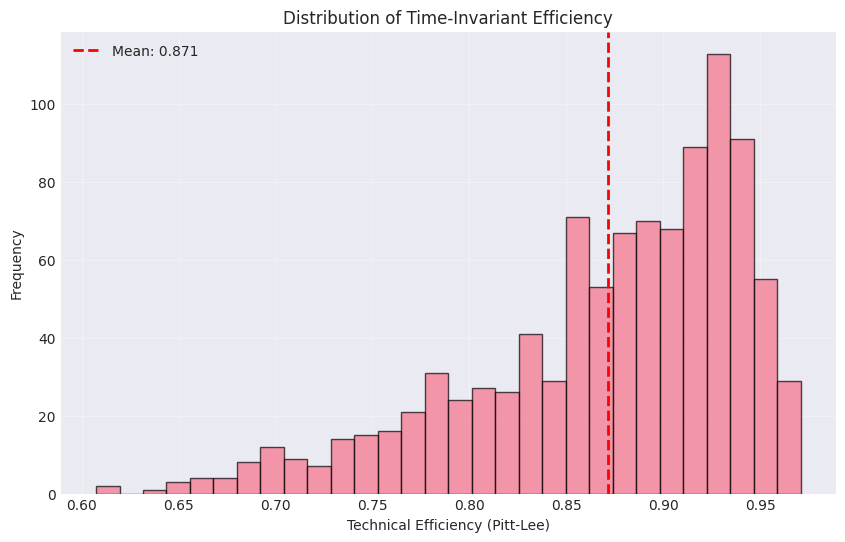

In [11]:
# Efficiency distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(efficiency_pl["efficiency"], bins=30, edgecolor="black", alpha=0.7)
ax.axvline(
    efficiency_pl["efficiency"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {efficiency_pl['efficiency'].mean():.3f}",
)
ax.set_xlabel("Technical Efficiency (Pitt-Lee)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Time-Invariant Efficiency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/02_panel/efficiency_pittlee.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Top/Bottom banks
print("Top 5 Most Efficient Banks:")
print(efficiency_pl.nlargest(5, "efficiency").to_string())

print("\nBottom 5 Least Efficient Banks:")
print(efficiency_pl.nsmallest(5, "efficiency").to_string())

Top 5 Most Efficient Banks:
     inefficiency  efficiency  ci_lower  ci_upper
254      0.029701    0.970735  1.000000       1.0
802      0.030310    0.970145  0.996713       1.0
806      0.031410    0.969078  0.987638       1.0
78       0.031639    0.968856  0.985827       1.0
552      0.032543    0.967980  0.978916       1.0

Bottom 5 Least Efficient Banks:
     inefficiency  efficiency  ci_lower  ci_upper
710      0.498505    0.607438  0.517424  0.708541
903      0.481934    0.617588  0.526069  0.720380
901      0.457364    0.632950  0.539155  0.738299
261      0.434515    0.647579  0.551616  0.755363
900      0.430035    0.650486  0.554093  0.758754


**Interpretation**: The Pitt-Lee model estimates a single efficiency score per bank across all years. This is appropriate when we believe efficiency is stable over time. The distribution shows the spread of bank efficiency in our sample.

---

## 6. Battese-Coelli 1992 (Time-Decay Inefficiency) <a id='6-bc92-model'></a>

The BC92 model allows inefficiency to change over time through an exponential decay function:

$$u_{it} = u_i \times \exp[-\eta(t - T)]$$

The key parameter $\eta$ captures whether firms are learning ($\eta > 0$) or degrading ($\eta < 0$).

In [13]:
# Estimate BC92 model (time-decay inefficiency)
bc92_model = StochasticFrontier(
    data=data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="bc92",
)

bc92_result = bc92_model.fit()

# Display results
print("=" * 60)
print("BATTESE-COELLI (1992) MODEL - TIME-DECAY INEFFICIENCY")
print("=" * 60)
print(bc92_result.summary())

BATTESE-COELLI (1992) MODEL - TIME-DECAY INEFFICIENCY
              Panel Stochastic Frontier Analysis Results (BC92)               
Model:                  bc92
Frontier:               production
Distribution:           half_normal
No. Observations:       1000
No. Entities:           100
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         575.0961
AIC:                    -1136.1922
BIC:                    -1101.8379
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.085588
  σ_u (inefficiency):   0.147507
  σ (composite):        0.170539
  λ = σ_u/σ_v:          1.723447
  γ = σ²_u/σ²:          0.748128
Temporal Parameters:
  η (decay parameter):  0.044489
    → Efficiency improves over time
------------------------------------------------------------------------------
------------------------------------------------------------------------------
Variance 

In [14]:
# Extract and interpret eta parameter
print("=" * 60)
print("TIME-DECAY PARAMETER")
print("=" * 60)

if hasattr(bc92_result, "temporal_params") and "eta" in bc92_result.temporal_params:
    eta = bc92_result.temporal_params["eta"]
    print(f"  eta (eta): {eta:.6f}")

    # Check if eta is in the params Series for SE
    if "eta" in bc92_result.params.index:
        eta_se = bc92_result.se["eta"]
        eta_tstat = bc92_result.tvalues["eta"]
        eta_pval = bc92_result.pvalues["eta"]
        print(f"  Std Error:    {eta_se:.6f}")
        print(f"  t-statistic:  {eta_tstat:.4f}")
        print(f"  P-value:      {eta_pval:.4f}")

    # Interpretation
    if eta > 0:
        print("\n  Interpretation: LEARNING (efficiency improves over time)")
        print("  Banks learn and become more efficient as time passes")
    elif eta < 0:
        print("\n  Interpretation: DEGRADATION (efficiency worsens over time)")
        print("  Banks become less efficient over time")
    else:
        print("\n  Interpretation: NO TIME EFFECT")
        print("  Efficiency is approximately time-invariant")
else:
    print("  eta parameter not found in temporal_params.")
    print(f"  Available params: {bc92_result.params.index.tolist()}")

TIME-DECAY PARAMETER
  eta (eta): 0.044489
  Std Error:    nan
  t-statistic:  nan
  P-value:      nan

  Interpretation: LEARNING (efficiency improves over time)
  Banks learn and become more efficient as time passes


In [15]:
# Calculate time-varying efficiency
efficiency_bc92 = bc92_result.efficiency(estimator="bc", by_period=True)

# Merge with original data
data_with_eff = data.copy()
data_with_eff["te_bc92"] = efficiency_bc92["efficiency"].values

print("BC92 Efficiency Summary (time-varying):")
print(f"  Mean TE:   {data_with_eff['te_bc92'].mean():.4f}")
print(f"  Std TE:    {data_with_eff['te_bc92'].std():.4f}")
print(f"  Min TE:    {data_with_eff['te_bc92'].min():.4f}")
print(f"  Max TE:    {data_with_eff['te_bc92'].max():.4f}")

BC92 Efficiency Summary (time-varying):
  Mean TE:   0.8700
  Std TE:    0.0744
  Min TE:    0.5831
  Max TE:    0.9722


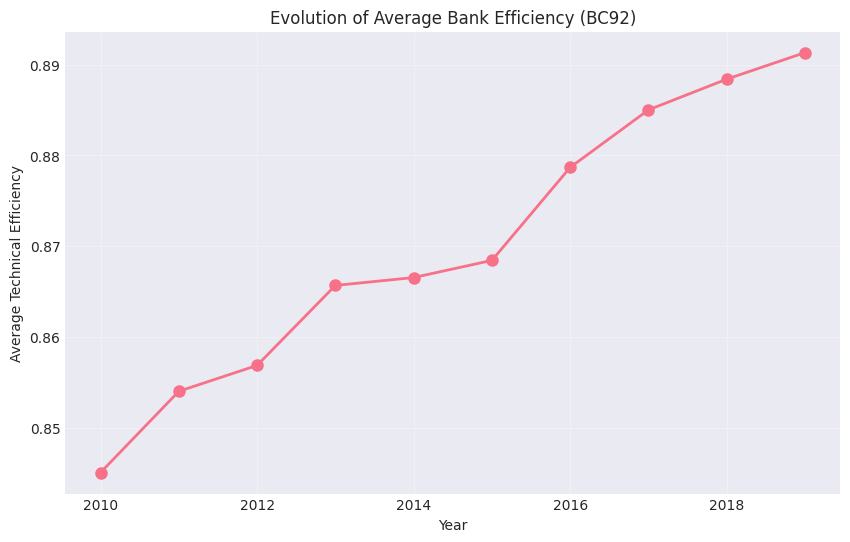

In [16]:
# Average efficiency by year
avg_eff_by_year = data_with_eff.groupby("year")["te_bc92"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg_eff_by_year.index, avg_eff_by_year.values, marker="o", linewidth=2, markersize=8)
ax.set_xlabel("Year")
ax.set_ylabel("Average Technical Efficiency")
ax.set_title("Evolution of Average Bank Efficiency (BC92)")
ax.grid(True, alpha=0.3)
plt.savefig(
    "../outputs/figures/02_panel/efficiency_evolution_bc92.png", dpi=300, bbox_inches="tight"
)
plt.show()

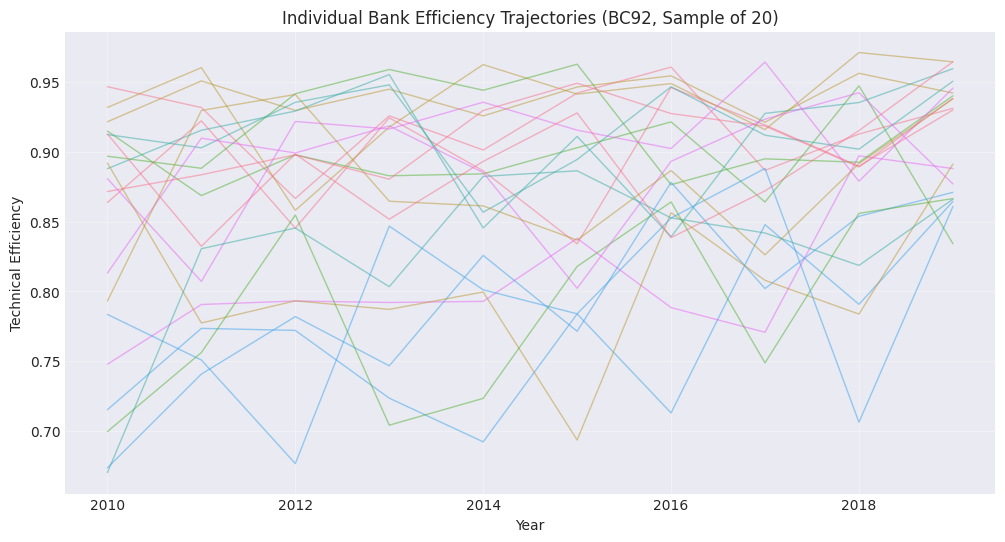

In [17]:
# Spaghetti plot of efficiency
fig, ax = plt.subplots(figsize=(12, 6))

sample_banks = data_with_eff["bank_id"].unique()[:20]
for bank_id in sample_banks:
    bank_data = data_with_eff[data_with_eff["bank_id"] == bank_id]
    ax.plot(bank_data["year"], bank_data["te_bc92"], alpha=0.5, linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Technical Efficiency")
ax.set_title("Individual Bank Efficiency Trajectories (BC92, Sample of 20)")
ax.grid(True, alpha=0.3)
plt.savefig(
    "../outputs/figures/02_panel/efficiency_spaghetti_bc92.png", dpi=300, bbox_inches="tight"
)
plt.show()

**Interpretation**: The BC92 model allows efficiency to change over time through the $\eta$ parameter. All banks share the same direction of change (learning or degradation), but the magnitude depends on each bank's base inefficiency $u_i$.

---

## 7. LR Test: Pitt-Lee vs BC92 <a id='7-lr-test'></a>

We test whether the time-decay parameter is significant:

- $H_0$: $\eta = 0$ (time-invariant inefficiency, Pitt-Lee)
- $H_1$: $\eta \neq 0$ (time-decay inefficiency, BC92)

In [18]:
# Likelihood ratio test: Pitt-Lee vs BC92
lr_result = lr_test(
    loglik_restricted=pittlee_result.loglik, loglik_unrestricted=bc92_result.loglik, df_diff=1
)

print("=" * 60)
print("LIKELIHOOD RATIO TEST: Pitt-Lee vs BC92")
print("=" * 60)
print("H0: eta = 0 (time-invariant inefficiency - Pitt-Lee)")
print("H1: eta != 0 (time-decay inefficiency - BC92)")
print(f"\nLog-likelihood (Pitt-Lee): {pittlee_result.loglik:.4f}")
print(f"Log-likelihood (BC92):     {bc92_result.loglik:.4f}")
print(f"\nLR Statistic: {lr_result['statistic']:.4f}")
print(f"Degrees of Freedom: {lr_result['df']}")
print(f"P-value: {lr_result['pvalue']:.4f}")
print(f"\nConclusion: {lr_result['conclusion']}")

if lr_result["pvalue"] < 0.05:
    print("  BC92 (time-varying) is significantly better than Pitt-Lee.")
    print("  Efficiency changes over time.")
else:
    print("  No evidence of time-varying efficiency.")
    print("  Pitt-Lee (time-invariant) is adequate.")

LIKELIHOOD RATIO TEST: Pitt-Lee vs BC92
H0: eta = 0 (time-invariant inefficiency - Pitt-Lee)
H1: eta != 0 (time-decay inefficiency - BC92)

Log-likelihood (Pitt-Lee): 563.5111
Log-likelihood (BC92):     575.0961

LR Statistic: 23.1699
Degrees of Freedom: 1
P-value: 0.0000

Conclusion: Reject H0
  BC92 (time-varying) is significantly better than Pitt-Lee.
  Efficiency changes over time.


In [19]:
# Model comparison table
comparison = pd.DataFrame(
    {
        "Model": ["Pitt-Lee", "BC92"],
        "Log-Likelihood": [pittlee_result.loglik, bc92_result.loglik],
        "AIC": [pittlee_result.aic, bc92_result.aic],
        "BIC": [pittlee_result.bic, bc92_result.bic],
        "N Parameters": [pittlee_result.nparams, bc92_result.nparams],
        "Mean TE": [efficiency_pl["efficiency"].mean(), data_with_eff["te_bc92"].mean()],
    }
)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))

MODEL COMPARISON
   Model  Log-Likelihood          AIC          BIC  N Parameters  Mean TE
Pitt-Lee      563.511115 -1115.022230 -1085.575698             6 0.871452
    BC92      575.096087 -1136.192174 -1101.837887             7 0.869994


---

## 8. Battese-Coelli 1995 (Inefficiency Determinants) <a id='8-bc95-model'></a>

The BC95 model allows covariates $Z_{it}$ to affect the **mean** of the inefficiency distribution:

$$\mu_{it} = Z_{it}'\delta$$

We include:
- `log_assets`: bank size
- `public_ownership`: state-owned bank dummy
- `npl_ratio`: non-performing loans ratio

In [20]:
# Estimate BC95 model with inefficiency determinants
bc95_model = StochasticFrontier(
    data=data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    inefficiency_vars=["log_assets", "public_ownership", "npl_ratio"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="truncated_normal",
    model_type="bc95",
)

bc95_result = bc95_model.fit()

# Display results
print("=" * 60)
print("BATTESE-COELLI (1995) MODEL - INEFFICIENCY DETERMINANTS")
print("=" * 60)
print(bc95_result.summary())

BATTESE-COELLI (1995) MODEL - INEFFICIENCY DETERMINANTS
                     Stochastic Frontier Analysis Results                     
Model:                  bc95
Frontier:               production
Distribution:           truncated_normal
No. Observations:       1000
No. Entities:           100
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         828.0800
AIC:                    -1636.1600
BIC:                    -1587.0825
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.069700
  σ_u (inefficiency):   0.087861
  σ (composite):        0.112150
  λ = σ_u/σ_v:          1.260571
  γ = σ²_u/σ²:          0.613756
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share):  0.6138
    95% CI:                [0.6138, 0.6138]
  λ (ratio σ_u/σ_v):       1.2606
    95% CI:                [1.2606,

In [21]:
# Extract inefficiency determinants (delta parameters)
print("=" * 60)
print("INEFFICIENCY DETERMINANTS (delta PARAMETERS)")
print("=" * 60)

# Look for delta parameters in the params
delta_params = [
    (name, bc95_result.params[name])
    for name in bc95_result.params.index
    if "delta" in name.lower() or name in ["log_assets", "public_ownership", "npl_ratio"]
]

# Display all parameters with interpretation
print(f"{'Parameter':<25} {'Coef':>10} {'Std Err':>10} {'t-stat':>10} {'P>|t|':>10}")
print("-" * 65)
for name in bc95_result.params.index:
    coef = bc95_result.params[name]
    se = bc95_result.se[name] if name in bc95_result.se.index else np.nan
    tval = bc95_result.tvalues[name] if name in bc95_result.tvalues.index else np.nan
    pval = bc95_result.pvalues[name] if name in bc95_result.pvalues.index else np.nan
    print(f"{name:<25} {coef:>10.4f} {se:>10.4f} {tval:>10.4f} {pval:>10.4f}")

print("\nInterpretation of delta parameters:")
print("  Positive delta -> variable INCREASES inefficiency (bad)")
print("  Negative delta -> variable DECREASES inefficiency (good)")

INEFFICIENCY DETERMINANTS (delta PARAMETERS)
Parameter                       Coef    Std Err     t-stat      P>|t|
-----------------------------------------------------------------
const                         1.5568        nan        nan        nan
log_labor                     0.2484        nan        nan        nan
log_capital                   0.2944        nan        nan        nan
log_deposits                  0.3965        nan        nan        nan
sigma_v_sq                    0.0049        nan        nan        nan
sigma_u_sq                    0.0077        nan        nan        nan
delta_const                   0.1185        nan        nan        nan
delta_log_assets             -0.0052        nan        nan        nan
delta_public_ownership        0.1887        nan        nan        nan
delta_npl_ratio               0.0187        nan        nan        nan

Interpretation of delta parameters:
  Positive delta -> variable INCREASES inefficiency (bad)
  Negative delta -> vari

In [22]:
# Marginal effects on inefficiency
try:
    me_results = bc95_result.marginal_effects(method="mean")
    print("=" * 60)
    print("MARGINAL EFFECTS ON INEFFICIENCY")
    print("=" * 60)
    print(me_results.to_string())
    print("\nInterpretation:")
    print("  Marginal effect = dE[u]/dz (change in expected inefficiency)")
    print("  Positive ME -> variable increases inefficiency")
    print("  Negative ME -> variable decreases inefficiency")

    # Save marginal effects table
    me_results.to_latex("../outputs/tables/latex/bc95_marginal_effects.tex", float_format="%.4f")
    me_results.to_html("../outputs/tables/html/bc95_marginal_effects.html", float_format="%.4f")
    print("\nMarginal effects tables saved.")
except Exception as e:
    print(f"Marginal effects not available: {e}")
    print("The delta parameters above provide directional interpretation.")

Marginal effects not available: "['const'] not in index"
The delta parameters above provide directional interpretation.


In [23]:
# Calculate BC95 efficiency
# BC95 returns SFResult (not PanelSFResult), so efficiency is per-observation
efficiency_bc95 = bc95_result.efficiency(estimator="bc")
data_with_eff["te_bc95"] = efficiency_bc95["efficiency"].values

print("BC95 Efficiency Summary:")
print(f"  Mean TE:   {data_with_eff['te_bc95'].mean():.4f}")
print(f"  Std TE:    {data_with_eff['te_bc95'].std():.4f}")
print(f"  Min TE:    {data_with_eff['te_bc95'].min():.4f}")
print(f"  Max TE:    {data_with_eff['te_bc95'].max():.4f}")

BC95 Efficiency Summary:
  Mean TE:   0.8779
  Std TE:    0.0640
  Min TE:    0.6559
  Max TE:    0.9763


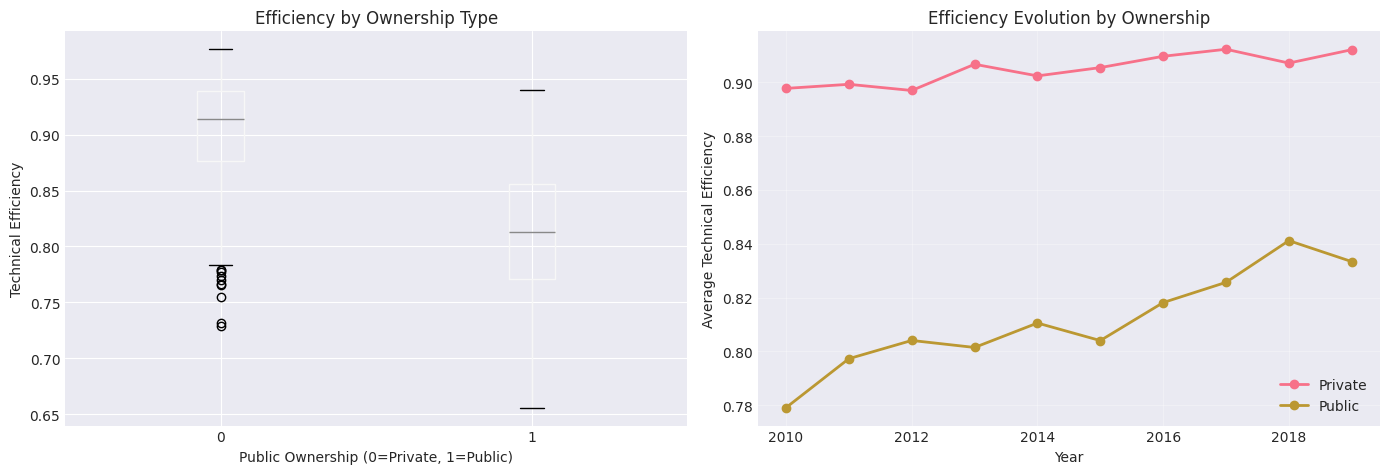

In [24]:
# Efficiency by ownership type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_with_eff.boxplot(column="te_bc95", by="public_ownership", ax=axes[0])
axes[0].set_xlabel("Public Ownership (0=Private, 1=Public)")
axes[0].set_ylabel("Technical Efficiency")
axes[0].set_title("Efficiency by Ownership Type")
axes[0].get_figure().suptitle("")

# Time series by ownership
for ownership in [0, 1]:
    subset = data_with_eff[data_with_eff["public_ownership"] == ownership]
    avg_eff = subset.groupby("year")["te_bc95"].mean()
    label = "Public" if ownership == 1 else "Private"
    axes[1].plot(avg_eff.index, avg_eff.values, marker="o", linewidth=2, label=label)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Technical Efficiency")
axes[1].set_title("Efficiency Evolution by Ownership")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/02_panel/efficiency_by_ownership.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Statistical test: Public vs Private efficiency
from scipy.stats import mannwhitneyu

public = data_with_eff[data_with_eff["public_ownership"] == 1]["te_bc95"]
private = data_with_eff[data_with_eff["public_ownership"] == 0]["te_bc95"]

stat, pval = mannwhitneyu(public, private, alternative="two-sided")

print("Mann-Whitney U Test (Public vs Private):")
print(f"  Mean TE (Public):  {public.mean():.4f}")
print(f"  Mean TE (Private): {private.mean():.4f}")
print(f"  U Statistic: {stat:.2f}")
print(f"  P-value: {pval:.4f}")

if pval < 0.05:
    print("  Conclusion: Significant difference in efficiency between ownership types.")
else:
    print("  Conclusion: No significant difference in efficiency.")

# Save determinants table
det_table = pd.DataFrame(
    {
        "Parameter": bc95_result.params.index,
        "Coefficient": bc95_result.params.values,
        "Std Error": bc95_result.se.values,
        "t-statistic": bc95_result.tvalues.values,
        "P-value": bc95_result.pvalues.values,
    }
)
det_table.to_latex(
    "../outputs/tables/latex/bc95_determinants.tex", index=False, float_format="%.4f"
)
det_table.to_html("../outputs/tables/html/bc95_determinants.html", index=False, float_format="%.4f")
print("\nDeterminants table saved.")

Mann-Whitney U Test (Public vs Private):
  Mean TE (Public):  0.8115
  Mean TE (Private): 0.9050
  U Statistic: 19474.00
  P-value: 0.0000
  Conclusion: Significant difference in efficiency between ownership types.

Determinants table saved.


---

## 9. Kumbhakar 1990 (Flexible Time Pattern) <a id='9-kumbhakar-model'></a>

The Kumbhakar (1990) model uses a logistic time function that allows **non-monotonic** efficiency patterns:

$$B(t) = \frac{1}{1 + \exp(b \cdot t + c \cdot t^2)}$$

In [26]:
# Estimate Kumbhakar (1990) model
kumbhakar_model = StochasticFrontier(
    data=data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="kumbhakar_1990",
)

kumbhakar_result = kumbhakar_model.fit()

# Display results
print("=" * 60)
print("KUMBHAKAR (1990) MODEL - FLEXIBLE TIME PATTERN")
print("=" * 60)
print(kumbhakar_result.summary())

KUMBHAKAR (1990) MODEL - FLEXIBLE TIME PATTERN
            Panel Stochastic Frontier Analysis Results (KUMBHAKAR)            
Model:                  kumbhakar_1990
Frontier:               production
Distribution:           half_normal
No. Observations:       1000
No. Entities:           100
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         602.7607
AIC:                    -1187.5213
BIC:                    -1143.3515
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.099372
  σ_u (inefficiency):   0.099372
  σ (composite):        0.140533
  λ = σ_u/σ_v:          1.000000
  γ = σ²_u/σ²:          0.500000
Temporal Parameters:
  b (linear term):      0.000000
  c (quadratic term):   0.000000
    → Kumbhakar (1990) flexible time pattern
------------------------------------------------------------------------------
-------------------------------------------

TIME PATTERN PARAMETERS
  b (linear term):    0.000000
  c (quadratic term): 0.000000

Time function: B(t) = 1 / [1 + exp(b*t + c*t^2)]


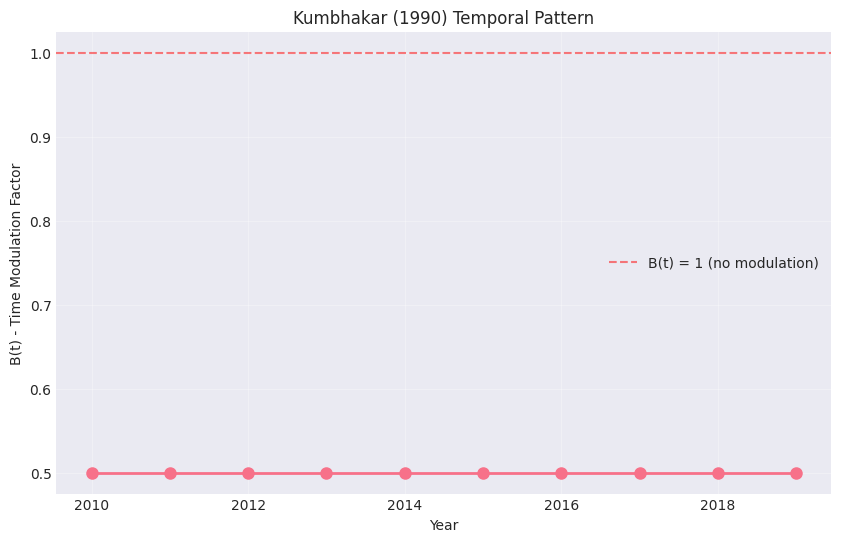

In [27]:
# Extract time parameters (b, c)
print("=" * 60)
print("TIME PATTERN PARAMETERS")
print("=" * 60)

if hasattr(kumbhakar_result, "temporal_params"):
    tp = kumbhakar_result.temporal_params
    b = tp.get("b", None)
    c = tp.get("c", None)

    if b is not None and c is not None:
        print(f"  b (linear term):    {b:.6f}")
        print(f"  c (quadratic term): {c:.6f}")
        print("\nTime function: B(t) = 1 / [1 + exp(b*t + c*t^2)]")

        # Plot time function
        years = np.arange(data["year"].min(), data["year"].max() + 1)
        t_values = years - data["year"].min() + 1  # Normalize to start at t=1
        B_t = 1 / (1 + np.exp(b * t_values + c * t_values**2))

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(years, B_t, marker="o", linewidth=2, markersize=8)
        ax.set_xlabel("Year")
        ax.set_ylabel("B(t) - Time Modulation Factor")
        ax.set_title("Kumbhakar (1990) Temporal Pattern")
        ax.grid(True, alpha=0.3)
        ax.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="B(t) = 1 (no modulation)")
        ax.legend()
        plt.savefig(
            "../outputs/figures/02_panel/kumbhakar_time_pattern.png", dpi=300, bbox_inches="tight"
        )
        plt.show()
    else:
        print(f"  Available temporal params: {tp}")
else:
    print("  No temporal_params found. Checking params:")
    print(f"  {kumbhakar_result.params.index.tolist()}")

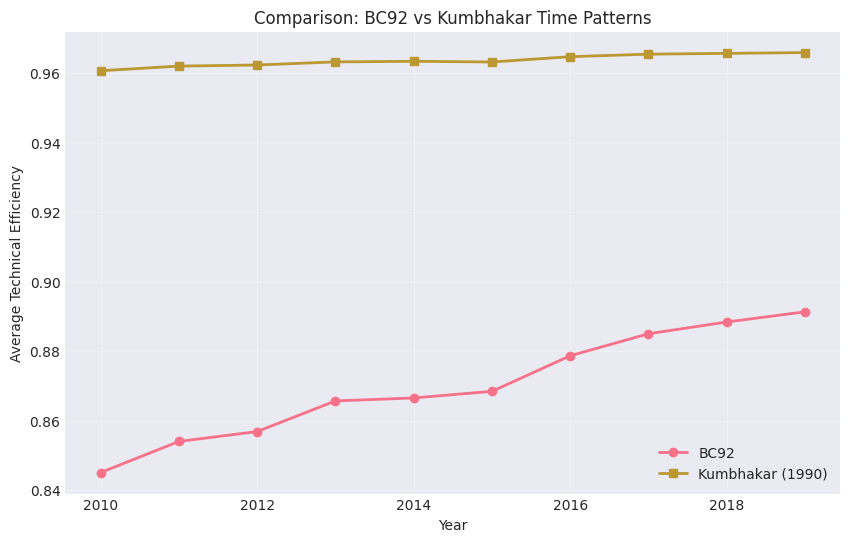

Mean TE (BC92):       0.8700
Mean TE (Kumbhakar):  0.9637


In [28]:
# Calculate Kumbhakar efficiency and compare with BC92
efficiency_kumbhakar = kumbhakar_result.efficiency(estimator="bc", by_period=True)
data_with_eff["te_kumbhakar"] = efficiency_kumbhakar["efficiency"].values

# Average by year
avg_bc92 = data_with_eff.groupby("year")["te_bc92"].mean()
avg_kumbhakar = data_with_eff.groupby("year")["te_kumbhakar"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg_bc92.index, avg_bc92.values, marker="o", linewidth=2, label="BC92")
ax.plot(
    avg_kumbhakar.index, avg_kumbhakar.values, marker="s", linewidth=2, label="Kumbhakar (1990)"
)
ax.set_xlabel("Year")
ax.set_ylabel("Average Technical Efficiency")
ax.set_title("Comparison: BC92 vs Kumbhakar Time Patterns")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/02_panel/bc92_vs_kumbhakar.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean TE (BC92):       {data_with_eff['te_bc92'].mean():.4f}")
print(f"Mean TE (Kumbhakar):  {data_with_eff['te_kumbhakar'].mean():.4f}")

---

## 10. CSS (Distribution-Free Method) <a id='10-css-model'></a>

The CSS (Cornwell, Schmidt & Sickles, 1990) method is **distribution-free**: it does not assume any specific distribution for $u$. Instead, it uses fixed effects to extract entity-level inefficiency.

In [29]:
# Estimate CSS model (distribution-free)
css_model = StochasticFrontier(
    data=data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    entity="bank_id",
    time="year",
    frontier="production",
    model_type="css",
    css_time_trend="linear",
)

css_result = css_model.fit()

# Display results
print("=" * 60)
print("CSS (CORNWELL-SCHMIDT-SICKLES) - DISTRIBUTION-FREE")
print("=" * 60)
try:
    print(css_result.summary())
except TypeError:
    # CSS does not have log-likelihood/AIC/BIC, so summary may fail
    print("Model Type:    CSS (Distribution-Free)")
    print("Time Trend:    linear")
    print(f"N Entities:    {data['bank_id'].nunique()}")
    print(f"N Periods:     {data['year'].nunique()}")
    print(f"N Observations:{len(data)}")
    if hasattr(css_result, "_css_result"):
        print(f"R-squared:     {css_result._css_result.r_squared:.4f}")
    print("\nNote: CSS is a distribution-free method - no MLE log-likelihood.")

CSS (CORNWELL-SCHMIDT-SICKLES) - DISTRIBUTION-FREE
Model Type:    CSS (Distribution-Free)
Time Trend:    linear
N Entities:    100
N Periods:     10
N Observations:1000
R-squared:     0.9949

Note: CSS is a distribution-free method - no MLE log-likelihood.


In [30]:
# Calculate CSS efficiency
try:
    if hasattr(css_result, "_css_result"):
        css_eff_entity = css_result._css_result.efficiency_by_entity()
        css_eff_period = css_result._css_result.efficiency_by_period()

        print("CSS Efficiency by Entity (first 10):")
        print(css_eff_entity.head(10).to_string())

        print("\nCSS Efficiency by Period:")
        print(css_eff_period.to_string())

        # Map entity efficiency to all observations
        # CSS uses 0-indexed entities, bank_id starts at 1
        unique_banks = sorted(data["bank_id"].unique())
        entity_eff_map = dict(zip(unique_banks, css_eff_entity["mean_efficiency"].values))
        data_with_eff["te_css"] = data_with_eff["bank_id"].map(entity_eff_map)
    else:
        css_efficiency = css_result.efficiency(estimator="bc")
        data_with_eff["te_css"] = css_efficiency["efficiency"].values

    print("\nCSS Efficiency Summary:")
    print(f"  Mean TE:   {data_with_eff['te_css'].mean():.4f}")
    print(f"  Std TE:    {data_with_eff['te_css'].std():.4f}")
    print(f"  Min TE:    {data_with_eff['te_css'].min():.4f}")
    print(f"  Max TE:    {data_with_eff['te_css'].max():.4f}")

except Exception as e:
    print(f"Error computing CSS efficiency: {e}")
    css_efficiency = css_result.efficiency(estimator="bc")
    data_with_eff["te_css"] = css_efficiency["efficiency"].values
    print("\nCSS Efficiency Summary (fallback):")
    print(f"  Mean TE: {data_with_eff['te_css'].mean():.4f}")

CSS Efficiency by Entity (first 10):


   entity  mean_efficiency  min_efficiency  max_efficiency  std_efficiency     trend
0       0         0.898079        0.850643        0.915772        0.022634 -0.006942
1       1         0.959664        0.934936        0.978486        0.012474 -0.001525
2       2         0.844140        0.793657        0.866967        0.024728 -0.007877
3       3         0.932714        0.907938        0.952973        0.013234  0.002361
4       4         0.682386        0.646148        0.699137        0.018647  0.005833
5       5         0.726028        0.685237        0.744329        0.021157  0.006718
6       6         0.819541        0.797026        0.837425        0.011880  0.002242
7       7         0.974468        0.916855        1.000000        0.030111  0.009673
8       8         0.925171        0.869847        0.950185        0.027099 -0.008632
9       9         0.897997        0.869784        0.914999        0.013169 -0.002571

CSS Efficiency by Period:
   period  mean_efficiency  min_effic

In [31]:
# Compare CSS vs BC92 (parametric vs distribution-free)
comparison_models = pd.DataFrame(
    {
        "Model": ["BC92 (Parametric)", "CSS (Distribution-Free)"],
        "Mean TE": [data_with_eff["te_bc92"].mean(), data_with_eff["te_css"].mean()],
        "Std TE": [data_with_eff["te_bc92"].std(), data_with_eff["te_css"].std()],
        "Min TE": [data_with_eff["te_bc92"].min(), data_with_eff["te_css"].min()],
        "Max TE": [data_with_eff["te_bc92"].max(), data_with_eff["te_css"].max()],
    }
)

print("=" * 60)
print("COMPARISON: SFA vs CSS")
print("=" * 60)
print(comparison_models.to_string(index=False))

COMPARISON: SFA vs CSS
                  Model  Mean TE   Std TE   Min TE   Max TE
      BC92 (Parametric) 0.869994 0.074366 0.583107 0.972247
CSS (Distribution-Free) 0.826080 0.096122 0.584680 0.983668


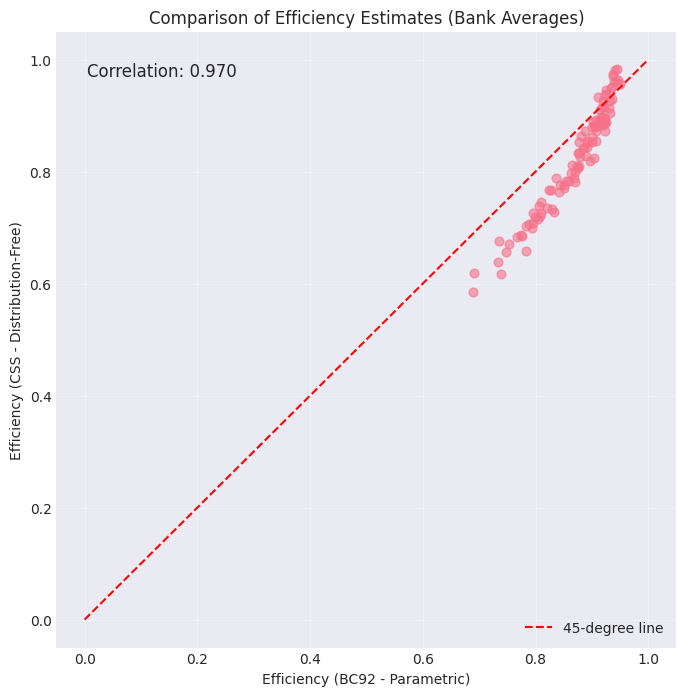


Interpretation:
  - CSS does not separate noise (v) from inefficiency (u)
  - CSS assumes the most efficient firm is on the frontier
  - Rank correlation of 0.970 indicates strong agreement
  - CSS is useful as a robustness check


In [32]:
# Scatter plot: BC92 vs CSS
fig, ax = plt.subplots(figsize=(8, 8))

# Average efficiency per bank for fair comparison
avg_bc92_by_bank = data_with_eff.groupby("bank_id")["te_bc92"].mean()
avg_css_by_bank = data_with_eff.groupby("bank_id")["te_css"].mean()

ax.scatter(avg_bc92_by_bank, avg_css_by_bank, alpha=0.6, s=40)
ax.plot([0, 1], [0, 1], "r--", label="45-degree line")

# Correlation
corr = avg_bc92_by_bank.corr(avg_css_by_bank)
ax.text(
    0.05,
    0.95,
    f"Correlation: {corr:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
)

ax.set_xlabel("Efficiency (BC92 - Parametric)")
ax.set_ylabel("Efficiency (CSS - Distribution-Free)")
ax.set_title("Comparison of Efficiency Estimates (Bank Averages)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/02_panel/sfa_vs_css.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  - CSS does not separate noise (v) from inefficiency (u)")
print("  - CSS assumes the most efficient firm is on the frontier")
print(
    f"  - Rank correlation of {corr:.3f} indicates {'strong' if abs(corr) > 0.7 else 'moderate'} agreement"
)
print("  - CSS is useful as a robustness check")

---

## 11. Comprehensive Model Comparison <a id='11-comprehensive-comparison'></a>

We now compare all estimated panel models using statistical criteria (AIC, BIC, log-likelihood) and efficiency estimates.

In [33]:
# Comprehensive model comparison
models_dict = {
    "Pitt-Lee": pittlee_result,
    "BC92": bc92_result,
    "BC95": bc95_result,
    "Kumbhakar": kumbhakar_result,
}

comparison_full = pd.DataFrame(
    {
        "Model": list(models_dict.keys()),
        "Log-Likelihood": [r.loglik for r in models_dict.values()],
        "AIC": [r.aic for r in models_dict.values()],
        "BIC": [r.bic for r in models_dict.values()],
        "N Parameters": [r.nparams for r in models_dict.values()],
        "Mean TE": [
            efficiency_pl["efficiency"].mean(),
            data_with_eff["te_bc92"].mean(),
            data_with_eff["te_bc95"].mean(),
            data_with_eff["te_kumbhakar"].mean(),
        ],
    }
)

# Add rankings (lower AIC/BIC is better)
comparison_full["AIC_Rank"] = comparison_full["AIC"].rank().astype(int)
comparison_full["BIC_Rank"] = comparison_full["BIC"].rank().astype(int)

print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)
print(comparison_full.to_string(index=False))

# Best model
best_aic_model = comparison_full.loc[comparison_full["AIC"].idxmin(), "Model"]
best_bic_model = comparison_full.loc[comparison_full["BIC"].idxmin(), "Model"]

print(f"\nBest Model by AIC: {best_aic_model}")
print(f"Best Model by BIC: {best_bic_model}")

COMPREHENSIVE MODEL COMPARISON
    Model  Log-Likelihood          AIC          BIC  N Parameters  Mean TE  AIC_Rank  BIC_Rank
 Pitt-Lee      563.511115 -1115.022230 -1085.575698             6 0.871452         4         4
     BC92      575.096087 -1136.192174 -1101.837887             7 0.869994         3         3
     BC95      828.080005 -1636.160010 -1587.082457            10 0.877869         1         1
Kumbhakar      602.760666 -1187.521331 -1143.351534             9 0.963664         2         2

Best Model by AIC: BC95
Best Model by BIC: BC95


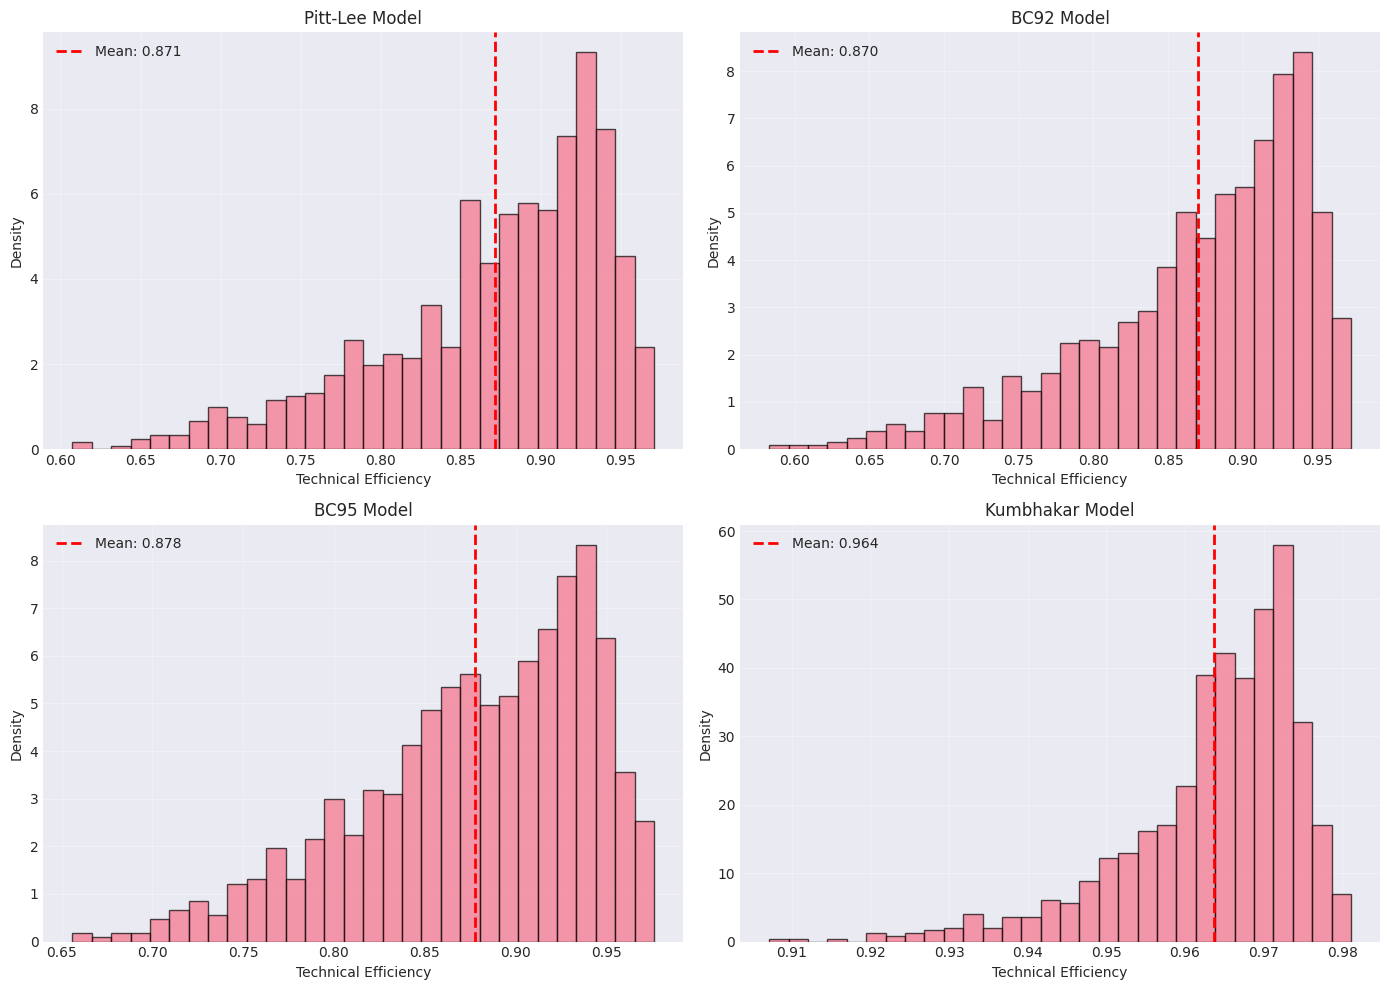

In [34]:
# Visualization: efficiency distributions for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_plot = [
    ("Pitt-Lee", efficiency_pl["efficiency"]),
    ("BC92", data_with_eff["te_bc92"]),
    ("BC95", data_with_eff["te_bc95"]),
    ("Kumbhakar", data_with_eff["te_kumbhakar"]),
]

for idx, (name, eff_data) in enumerate(models_plot):
    ax = axes[idx // 2, idx % 2]
    ax.hist(eff_data, bins=30, density=True, alpha=0.7, edgecolor="black")
    ax.axvline(
        eff_data.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {eff_data.mean():.3f}",
    )
    ax.set_xlabel("Technical Efficiency")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} Model")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/02_panel/all_models_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# Export comparison tables
comparison_full.to_latex(
    "../outputs/tables/latex/panel_models_comparison.tex", index=False, float_format="%.4f"
)
comparison_full.to_html(
    "../outputs/tables/html/panel_models_comparison.html", index=False, float_format="%.4f"
)

print("Tables exported to:")
print("  - ../outputs/tables/latex/panel_models_comparison.tex")
print("  - ../outputs/tables/html/panel_models_comparison.html")

Tables exported to:
  - ../outputs/tables/latex/panel_models_comparison.tex
  - ../outputs/tables/html/panel_models_comparison.html


---

## 12. Practical Exercises <a id='12-exercises'></a>

### Exercise 1: Airline Efficiency Analysis (Easy)

Load `airline_panel.csv` and:
1. Estimate Pitt-Lee and BC92 models for airline production
2. Test if efficiency changed over time (LR test)
3. Identify airlines with learning vs degradation
4. Visualize efficiency evolution

**Variables**:
- Dependent: `log_pass_km` (passenger-kilometers)
- Inputs: `log_aircraft`, `log_employees`, `log_fuel`
- Entity: `airline_id`, Time: `year`

In [36]:
# Exercise 1: YOUR CODE HERE
# Step 1: Load airline data
# airline_data = pd.read_csv('../data/airline_panel.csv')

# Step 2: Estimate Pitt-Lee model

# Step 3: Estimate BC92 model

# Step 4: LR test

# Step 5: Visualize efficiency evolution


### Exercise 2: Policy Simulation (Medium)

Using the bank data and the BC95 model:
1. Estimate a BC95 model with `public_ownership` and `npl_ratio` as determinants
2. **Policy simulation**: What would happen if all public banks were privatized?
   - Create a counterfactual dataset where `public_ownership = 0` for all banks
   - Compare predicted efficiency under both scenarios
3. Estimate the aggregate efficiency gain from privatization

In [37]:
# Exercise 2: YOUR CODE HERE
# Step 1: Use the BC95 model already estimated above (bc95_result)

# Step 2: Create counterfactual data (set public_ownership=0 for all)

# Step 3: Re-estimate or predict efficiency under counterfactual

# Step 4: Compare and report efficiency gains


### Exercise 3: Comprehensive Model Selection (Hard)

Using the airline data:
1. Estimate **all** panel models: Pitt-Lee, BC92, Kumbhakar, CSS
2. Create a comprehensive comparison table with AIC, BIC, log-likelihood, and mean TE
3. Justify your model selection based on:
   - Statistical criteria (AIC/BIC rankings)
   - Economic interpretation (does the time pattern make sense?)
   - Robustness (CSS as a check)
4. Report your findings in a structured summary

In [38]:
# Exercise 3: YOUR CODE HERE
# Step 1: Load airline data and estimate all models

# Step 2: Create comparison table

# Step 3: Analyze and justify selection

# Step 4: Write summary


---

## 13. Conclusions and Next Steps <a id='13-conclusions'></a>

### Key Findings

1. **Panel SFA** provides richer insights than cross-sectional analysis by tracking efficiency over time
2. **Time-invariant models** (Pitt-Lee) are simple but restrictive; test for time variation
3. **Time-decay models** (BC92) capture monotonic trends with a single parameter $\eta$
4. **Determinants models** (BC95) explain *why* some firms are more efficient
5. **Flexible models** (Kumbhakar) allow non-monotonic time patterns
6. **Distribution-free methods** (CSS) serve as important robustness checks

### Model Selection Criteria

| Criterion | When to Use |
|-----------|------------|
| LR test | Nested models (Pitt-Lee vs BC92) |
| AIC | Non-nested models, focus on prediction |
| BIC | Non-nested models, focus on parsimony |
| Economic theory | Always consider if results make sense |
| CSS comparison | Robustness of efficiency rankings |

### Next Tutorial

In **Tutorial 03: Four-Component Model and TFP**, we will explore:
- The Kumbhakar et al. (2014) four-component model
- Separation of persistent and transient inefficiency
- Total Factor Productivity decomposition
- True Fixed Effects and True Random Effects models

---

## 14. References <a id='14-references'></a>

1. **Pitt, M.M., & Lee, L.F. (1981)**. "The measurement and sources of technical inefficiency in the Indonesian weaving industry." *Journal of Development Economics*, 9(1), 43-64.

2. **Battese, G.E., & Coelli, T.J. (1992)**. "Frontier production functions, technical efficiency and panel data: With application to paddy farmers in India." *Journal of Productivity Analysis*, 3(1-2), 153-169.

3. **Battese, G.E., & Coelli, T.J. (1995)**. "A model for technical inefficiency effects in a stochastic frontier production function for panel data." *Empirical Economics*, 20(2), 325-332.

4. **Kumbhakar, S.C. (1990)**. "Production frontiers, panel data, and time-varying technical inefficiency." *Journal of Econometrics*, 46(1-2), 201-211.

5. **Schmidt, P., & Sickles, R.C. (1984)**. "Production frontiers and panel data." *Journal of Business & Economic Statistics*, 2(4), 367-374.

6. **Cornwell, C., Schmidt, P., & Sickles, R.C. (1990)**. "Production frontiers with cross-sectional and time-series variation in efficiency levels." *Journal of Econometrics*, 46(1-2), 185-200.